# VAE

In [3]:
%reload_ext watermark
%watermark -a 'Yasir Awais Butt' -v -p torch

Author: Yasir Awais Butt

Python implementation: CPython
Python version       : 3.12.3
IPython version      : 9.13.0

torch: 2.11.0+cu128



# Imports

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
# Hyperparameters
BATCH_SIZE = 256
LEARNING_RATE = 0.0005
EPOCHS = 20
LATENT_DIM = 2
RANDOM_SEED = 42
# Load MNIST dataset
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root = "../../data",
                               train = True,
                               transform = transform,
                               download = True)
test_dataset = datasets.MNIST(root = "../../data",
                              train = False,
                              transform = transform,
                              download = True)
test_loader = DataLoader(test_dataset, 
                         batch_size = BATCH_SIZE, 
                         shuffle = False)
train_loader = DataLoader(train_dataset, 
                          batch_size = BATCH_SIZE, 
                          num_workers = 2,
                          shuffle = True)

Using device: cuda


In [13]:
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
for images, labels in train_loader:
    print(f"Batch of images shape: {images.shape}")
    print(f"Batch of labels shape: {labels.shape}")
    break


Number of training samples: 60000
Number of test samples: 10000
Batch of images shape: torch.Size([256, 1, 28, 28])
Batch of labels shape: torch.Size([256])


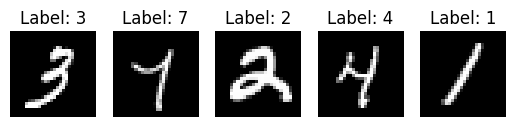

In [ ]:
for i in range(5):
    images, labels = next(iter(train_loader))
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[0].squeeze(), cmap = "gray")
    plt.title(f"Label: {labels[0].item()}")
    plt.axis("off")
plt.show()

In [16]:
print(f"Number of testing samples: {len(test_dataset)}")
for images, labels in test_loader:
    print(f"Batch of images shape: {images.shape}")
    print(f"Batch of labels shape: {labels.shape}")
    break

Number of testing samples: 10000
Batch of images shape: torch.Size([256, 1, 28, 28])
Batch of labels shape: torch.Size([256])


In [18]:
import numpy as np
import random

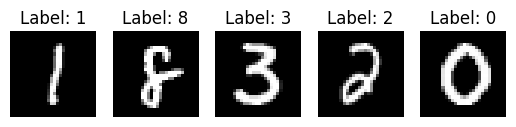

In [25]:
for i in range(5):
    idx = random.randrange(len(test_dataset))
    images, labels = test_dataset[idx]
    plt.subplot(1, 5, i+1)
    plt.imshow(images[0].squeeze(), cmap = "gray")
    plt.title(f"Label: {labels}")
    plt.axis("off")
plt.show()

# Model

In [26]:
class Reshape(nn.Module):
    def __init__(self, *args):
        super(Reshape, self).__init__()
        self.shape = args

    def forward(self, x):
        return x.view(self.shape)
class Trim(nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.shape = args

    def forward(self, x):
        return x[:, :, :28, :28]

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim 
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size = 3, stride = 1, padding = 1),  # (B, 32, 28, 28)
            nn.LeakyReLU(0.01),
            nn.Conv2d(32, 64, kernel_size = 3, stride = 2, padding = 1), # (B, 64, 14, 14)
            nn.LeakyReLU(0.01),
            nn.Conv2d(64, 64, kernel_size = 3, stride = 2, padding = 1), # (B, 64, 7, 7)
            nn.LeakyReLU(0.01),
            nn.Conv2d(64, 64, kernel_size = 3, stride = 1, padding = 1), # (B, 64, 7, 7)
            nn.Flatten()
        )
        self.z_mean = nn.Linear(64 * 7 * 7, latent_dim)
        self.z_log_var = nn.Linear(64 * 7 * 7, latent_dim)
        #Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * 7 * 7),
            Reshape(-1, 64, 7, 7),
            nn.ConvTranspose2d(64, 64, kernel_size = 3, stride = 1, padding = 1), # (B, 64, 7, 7)
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(64, 64, kernel_size = 3, stride = 2, padding = 1, output_padding = 1), # (B, 64, 14, 14)
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(64, 32, kernel_size = 3, stride = 2, padding = 1, output_padding = 1), # (B, 32, 28, 28)
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(32, 1, kernel_size = 3, stride = 1, padding = 1), # (B, 1, 28, 28)
            Trim(),
            nn.Sigmoid()
        )
    def encoding_fn(self, x):
        h = self.encoder(x)
        z_mean = self.z_mean(h)
        z_log_var = self.z_log_var(h)
        encoded = self.reparametrize(z_mean, z_log_var)
        return encoded
    def reparametrize(self, z_mean, z_log_var):
        eps = torch.randn(z_mean.size(0), z_mean.size(1)).to(DEVICE)
        z = z_mean + eps*torch.exp(z_log_var / 2)
        return z
    def forward(self, x):
        z_mean, z_log_var = self.z_mean(self.encoder(x)), self.z_log_var(self.encoder(x))
        encoded = self.reparametrize(z_mean, z_log_var)
        reconstructed = self.decoder(encoded)
        return encoded, reconstructed, z_mean, z_log_var
    